In [6]:
import os
import time

from SI.Practical_TM_SI import practical_TM_SI_randj
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Ananconda\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Ananconda\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Ananconda\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Ananconda\Lib\site-packages\tornado\platform\asyncio.py", line 205, in 

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [7]:
p, nt, ns, K = 100, 30, 50, 2
V = 3
sigma = 1.0
n_rep = 500
#n_jobs = os.cpu_count()   # use every logical core
n_jobs = 12

In [8]:
print(n_jobs)

12


In [9]:
rng = np.random.default_rng(2026)

X0 = rng.standard_normal((nt, p))
X_list = [rng.standard_normal((ns, p)) for _ in range(K)]

Sigma_0 = sigma ** 2 * np.eye(nt)
Sigma_K = [sigma ** 2 * np.eye(ns) for _ in range(K)]

In [10]:
p_values, branches, seconds = [], [], []   # filled during the run, so a stopped run keeps them
kkt = {"observed fits": 0, "observed violations": 0, "SI fits": 0, "SI violations": 0}


def run(n_rep):
    n_empty = 0
    start = time.perf_counter()

    for i in range(1, n_rep + 1):
        y0 = sigma * rng.standard_normal(nt)
        y_list = [sigma * rng.standard_normal(ns) for _ in range(K)]

        t = time.perf_counter()
        result = practical_TM_SI_randj(
            X0, y0, X_list, y_list, Sigma_0, Sigma_K,
            V=V, rng=rng, n_jobs=n_jobs,
        )

        kkt["observed fits"] += result['kkt_observed']['fits']
        kkt["observed violations"] += result['kkt_observed']['violations']
        if result['results']:
            p_values.append(result['results'][0]['p_value'])
            branches.append(result['branch'])
            seconds.append(time.perf_counter() - t)
            kkt["SI fits"] += result['results'][0]['kkt_si']['fits']
            kkt["SI violations"] += result['results'][0]['kkt_si']['violations']
        else:
            n_empty += 1

        if i % 10 == 0:
            print(f"{i}/{n_rep}, "
                  f"p-values: {len(p_values)}, "
                  f"empty models: {n_empty}, "
                  f"time: {time.perf_counter() - start:.0f}s, "
                  f"KKT violations: observed {kkt['observed violations']}/{kkt['observed fits']}, "
                  f"SI {kkt['SI violations']}/{kkt['SI fits']}")

    return np.array(p_values), branches, n_empty

In [11]:
list_p_value, branches, n_empty = run(n_rep)

10/500, p-values: 2, empty models: 8, time: 50s, KKT violations: observed 0/4000, SI 0/66200
20/500, p-values: 5, empty models: 15, time: 110s, KKT violations: observed 0/8000, SI 0/161284
30/500, p-values: 7, empty models: 23, time: 139s, KKT violations: observed 0/12000, SI 1/205412
40/500, p-values: 12, empty models: 28, time: 246s, KKT violations: observed 0/16000, SI 2/369985
50/500, p-values: 16, empty models: 34, time: 331s, KKT violations: observed 0/20000, SI 2/498998
60/500, p-values: 19, empty models: 41, time: 395s, KKT violations: observed 0/24000, SI 2/582679
70/500, p-values: 23, empty models: 47, time: 475s, KKT violations: observed 0/28000, SI 4/709169
80/500, p-values: 28, empty models: 52, time: 583s, KKT violations: observed 0/32000, SI 6/870832
90/500, p-values: 30, empty models: 60, time: 619s, KKT violations: observed 0/36000, SI 6/926617
100/500, p-values: 35, empty models: 65, time: 712s, KKT violations: observed 0/40000, SI 6/1059418
110/500, p-values: 38, emp

In [12]:
print(f"tests: {list_p_value.size}, empty models: {n_empty}")
print({b: branches.count(b) for b in sorted(set(branches))})
print(f"KKT violations: observed {kkt['observed violations']} / {kkt['observed fits']} fits, "
      f"SI {kkt['SI violations']} / {kkt['SI fits']} fits")

tests: 203, empty models: 297
{'transmission': 203}
KKT violations: observed 2 / 200000 fits, SI 27 / 6403593 fits


In [13]:
alpha = 0.05
FPR = np.mean(list_p_value <= alpha)
print(f"FPR = {FPR}")

FPR = 0.059113300492610835


In [14]:
statistic, p_value = stats.kstest(list_p_value, 'uniform')
print(f'KS-Test statistic = {statistic}')
print(f'KS-Test p-value = {p_value}')

KS-Test statistic = 0.09832890776484443
KS-Test p-value = 0.036803419927639025


(array([12., 12., 15., 10., 14., 17.,  6.,  6.,  9., 14.,  9., 11., 13.,
        10.,  4.,  7.,  6., 12.,  5., 11.]),
 array([0.00705103, 0.05603442, 0.10501782, 0.15400122, 0.20298461,
        0.25196801, 0.3009514 , 0.3499348 , 0.39891819, 0.44790159,
        0.49688499, 0.54586838, 0.59485178, 0.64383517, 0.69281857,
        0.74180196, 0.79078536, 0.83976876, 0.88875215, 0.93773555,
        0.98671894]),
 <BarContainer object of 20 artists>)

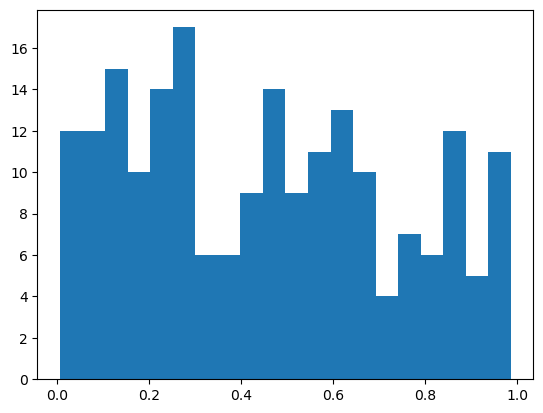

In [15]:
plt.hist(list_p_value, bins=20)

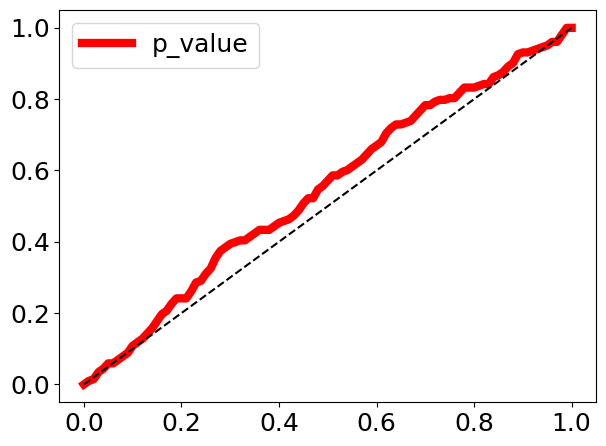

In [16]:
plt.rcParams.update({'font.size': 18})
grid = np.linspace(0, 1, 101)
ecdf = np.searchsorted(np.sort(list_p_value), grid, side='right') / len(list_p_value)
plt.plot(grid, ecdf, 'r-', linewidth=6, label='p_value')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.tight_layout()
plt.show()